### Linear MPC



#### Задача 1

Выведите линейный MPC для следования траектории $X = \{x_{i+1}^*\}_{i=0}^{N-1}$. Вывод слегка обобщает лекционный результат. 

В функцию коста добавим целевую траекторию:
$$ J = \sum_{i=0}^{N-1} \left[ (x_{i+1} - x_{i+1}^*)^\top Q (x_{i+1} - x_{i+1}^*) + u_i^\top \hat{R} u_i \right] $$
$$ = (\hat{A} x_0 + \hat{B} U - x^*)^\top \hat{Q} (\hat{A} x_0 + \hat{B} U - x^*) + U^\top \hat{R} U $$
$$ = x_0^\top \hat{A}^\top \hat{Q} \hat{A} x_0 + U^\top \hat{B}^\top \hat{Q} \hat{B} U + x^{*\top} \hat{Q} x^* + 2 x_0^\top \hat{A}^\top \hat{Q} \hat{B} U - 2 x_0^\top \hat{A}^\top \hat{Q} x^* - 2 U^\top \hat{B}^\top \hat{Q} x^* + U^\top \hat{R} U $$

Продифференцируем по $U$ и приравняем к нулю:
$$ \frac{\partial G}{\partial U} = 2 (\hat{B}^\top \hat{Q} \hat{B} + \hat{R}) U + 2 \hat{B}^\top \hat{Q} \hat{A} x_0 - 2 \hat{B}^\top \hat{Q} x^* = 0 \iff $$
$$ U = (\hat{B}^\top \hat{Q} \hat{B} + \hat{R})^{-1} (\hat{B}^\top \hat{Q} x^* - \hat{B}^\top \hat{Q} \hat{A} x_0) $$

#### Задача 2

Реализуйте функцию generate_controls, следуя выводу из первой задачи. Она должна генерировать для заданной системы последовательность управлений, оптимальную в смысле квадратичной функции стоимости. Горизонт известен, начальное состояние известно.

Для тестирования задайте
- траекторию X_star (икс со звездой, желаемая траектория)
- матрицу системы, соответствующую динамической точке (дискретизованной, dt возьмите 1 секунду)
- матрицу управления для нее

In [1]:
from typing import Tuple
import numpy as np


def build_hat_matrices(
    x_0: np.ndarray,
    X_star: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    N: int,
    Q: np.ndarray,
    R: np.ndarray,
):
    n = x_0.shape[0]
    m = R.shape[0]

    def assert_shape(arr: np.ndarray, shape: Tuple[int, ...]):
        assert arr.shape == shape, f"Expected shape {shape}, got {arr.shape}"

    assert_shape(x_0, (n,))
    assert_shape(X_star, (N * n,))
    assert_shape(A, (n, n))
    assert_shape(B, (n, m))
    assert_shape(Q, (n, n))
    assert_shape(R, (m, m))

    B_hat = np.zeros((N * n, N * m))
    Q_hat = np.zeros((N * n, N * n))
    R_hat = np.zeros((N * m, N * m))
    A_pow = [np.eye(n)]
    for i in range(N):
        A_pow.append(A_pow[-1] @ A)
    A_pow = A_pow[1:]
    A_hat = np.concat(A_pow, axis=0)
    for i in range(N):
        j = 0
        while j < i:
            B_hat[i * n : (i + 1) * n, j * m : (j + 1) * m] = A_pow[i - j - 1] @ B
            j += 1
        B_hat[i * n : (i + 1) * n, j * m : (j + 1) * m] = B
        Q_hat[i * n : (i + 1) * n, i * n : (i + 1) * n] = Q
        R_hat[i * m : (i + 1) * m, i * m : (i + 1) * m] = R

    return A_hat, B_hat, Q_hat, R_hat


def generate_controls(
    x_0: np.ndarray,
    X_star: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    N: int,
    Q: np.ndarray,
    R: np.ndarray,
):
    A_hat, B_hat, Q_hat, R_hat = build_hat_matrices(x_0, X_star, A, B, N, Q, R)

    B_hat_T_Q_hat = B_hat.T @ Q_hat
    a = B_hat_T_Q_hat @ B_hat + R_hat
    b = B_hat_T_Q_hat @ X_star - B_hat_T_Q_hat @ A_hat @ x_0
    U = np.linalg.solve(a, b)

    return U


dt = 1
m = 10

A = np.array([[1, dt], [0, 1]], dtype=np.float32)

B = np.array([[dt * dt / 2], [dt]]) / m

Q = np.eye(2)

R = np.eye(1)

horizon = 3

x_0 = np.array([10, 1])

X_star = np.array(
    [
        11,
        1,
        12,
        1,
        13,
        1,
    ],
    dtype=np.float32,
)

print(generate_controls(x_0, X_star, A, B, horizon, Q, R))

[-2.46768733e-17  4.26614974e-16 -6.82521718e-18]


#### Задача 3

Реализуйте ту же функцию generate_controls, но поставив задачу поиска оптимальной последовательности управлений как задачу квадратичного программирования и решив ее с помощью *solve_qp*. Учтите ограничения на управление (F_max = 3 Н).

In [2]:
import numpy as np
from qpsolvers import solve_qp


def generate_controls(
    x_0: np.ndarray,
    X_star: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    N: int,
    Q: np.ndarray,
    R: np.ndarray,
):
    A_hat, B_hat, Q_hat, R_hat = build_hat_matrices(x_0, X_star, A, B, N, Q, R)
    B_hat_T_Q_hat = B_hat.T @ Q_hat
    P = B_hat_T_Q_hat @ B_hat + R_hat
    q = B_hat_T_Q_hat @ A_hat @ x_0 - B_hat_T_Q_hat @ X_star

    G = np.vstack([np.eye(N), -np.eye(N)])
    h = np.hstack([np.full(N, 3.0), np.full(N, 3.0)])

    U = solve_qp(P=P, q=q, G=G, h=h, solver="osqp")

    return U


print(generate_controls(x_0, X_star, A, B, horizon, Q, R))

[-2.46768733e-17  4.26614974e-16 -6.82521718e-18]


/Users/n-zagainov/.local/share/mamba/envs/aim/lib/python3.12/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/Users/n-zagainov/.local/share/mamba/envs/aim/lib/python3.12/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'G' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


#### Задача 4

Примените функцию generate_controls для управления динамической точкой с массой. Визуализируйте результат.

Попробуйте горизонт 5, 10, 15. Измерьте время вычисления траектории во всех этих случаях.

In [3]:
from typing import Optional, Callable
from collections import defaultdict
from functools import partial
import time
import cv2


class PointWithMassSimulator:
    def __init__(self, dt: float = 1.0, m: float = 10):
        self.dt = dt
        self.m = 10
        self.A = np.array([[1, dt], [0, 1]], dtype=np.float32)
        self.B = np.array([[dt * dt / 2], [dt]]) / m
        self.x = None
        self.t = None

    def reset(self, state: Optional[np.ndarray] = None):
        if state is None:
            state = np.array([10, 1], dtype=np.float32)
        self.x = state
        self.t = 0

    def step(self, u: np.ndarray):
        self.t += self.dt
        self.x = self.A @ self.x + self.B @ u

    def render(self):
        height, width = 400, 1000
        img = np.ones((height, width, 3), dtype=np.uint8) * 255

        pos, vel = self.x[0], self.x[1]

        scale = 10
        center_x = width // 2
        center_y = height // 2

        pixel_x = int(center_x + pos * scale)
        pixel_x = np.clip(pixel_x, 10, width - 10)

        cv2.line(img, (0, center_y), (width, center_y), (200, 200, 200), 2)

        for i in range(-40, 41, 5):
            marker_x = center_x + i * scale
            if 0 <= marker_x < width:
                cv2.line(img, (marker_x, center_y - 5), (marker_x, center_y + 5), (150, 150, 150), 1)
                cv2.putText(
                    img, str(i), (marker_x - 10, center_y + 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1
                )

        cv2.circle(img, (pixel_x, center_y), 15, (0, 0, 255), -1)

        vel_scale = 10
        arrow_end_x = int(pixel_x + vel * vel_scale)
        if abs(vel) > 0.1:
            cv2.arrowedLine(img, (pixel_x, center_y), (arrow_end_x, center_y), (0, 255, 0), 2, tipLength=0.3)

        cv2.putText(img, f"Time: {self.t:.2f}s", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
        cv2.putText(img, f"Position: {pos:.2f}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
        cv2.putText(img, f"Velocity: {vel:.2f}", (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

        return img

    def simulate(
        self,
        control_fn: Callable[[np.ndarray, np.ndarray, np.ndarray, int], np.ndarray],
        num_steps: int,
        render_freq: int = -1,
        init_state: Optional[np.ndarray] = None,
    ):
        self.reset(init_state)
        frames = []
        x_traj = []
        u_traj = []
        times = []
        if render_freq > 0:
            frames.append(self.render())

        for step in range(num_steps):
            start = time.perf_counter()
            u = control_fn(self.x, self.A, self.B, self.dt)
            times.append(time.perf_counter() - start)
            self.step(u)
            x_traj.append(self.x.copy())
            u_traj.append(u)

            if render_freq > 0 and (step + 1) % render_freq == 0:
                frames.append(self.render())

        x_traj = np.stack(x_traj)
        u_traj = np.stack(u_traj)

        if render_freq > 0:
            return x_traj, u_traj, np.mean(times), frames

        return x_traj, u_traj, np.mean(times)


def control_fn(
    x: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    dt: float,
    Q: np.ndarray,
    R: np.ndarray,
    objective: float,
    horizon: int,
):
    pos = x[0]

    distance = objective - pos
    direction = np.sign(distance) if distance != 0 else 0

    X_star = []

    for i in range(1, horizon + 1):
        distance_moved = 1.0 * dt * i

        if abs(distance) > distance_moved:
            desired_pos = pos + direction * distance_moved
            desired_vel = 1.0 * direction
        else:
            desired_pos = objective
            desired_vel = 0.0

        X_star.append(np.array([desired_pos, desired_vel]))

    X_star = np.concat(X_star, axis=0)

    U = generate_controls(x, X_star, A, B, horizon, Q, R)

    return U[:1]


Q = np.eye(2)
R = np.eye(1)

horizons = [5, 10, 15]
stats = defaultdict(dict)
vids = dict()
dt = 0.05
simulator = PointWithMassSimulator(dt=dt, m=2)

for horizon in horizons:
    x_traj, u_traj, avg_mpc_time, frames = simulator.simulate(
        control_fn=partial(control_fn, Q=Q, R=R, objective=0, horizon=horizon),
        num_steps=1000,
        render_freq=10,
    )
    stats[horizon]["x_traj"] = x_traj
    stats[horizon]["u_traj"] = u_traj
    stats[horizon]["avg_mpc_time"] = avg_mpc_time
    vids[f"horizon={horizon}"] = frames


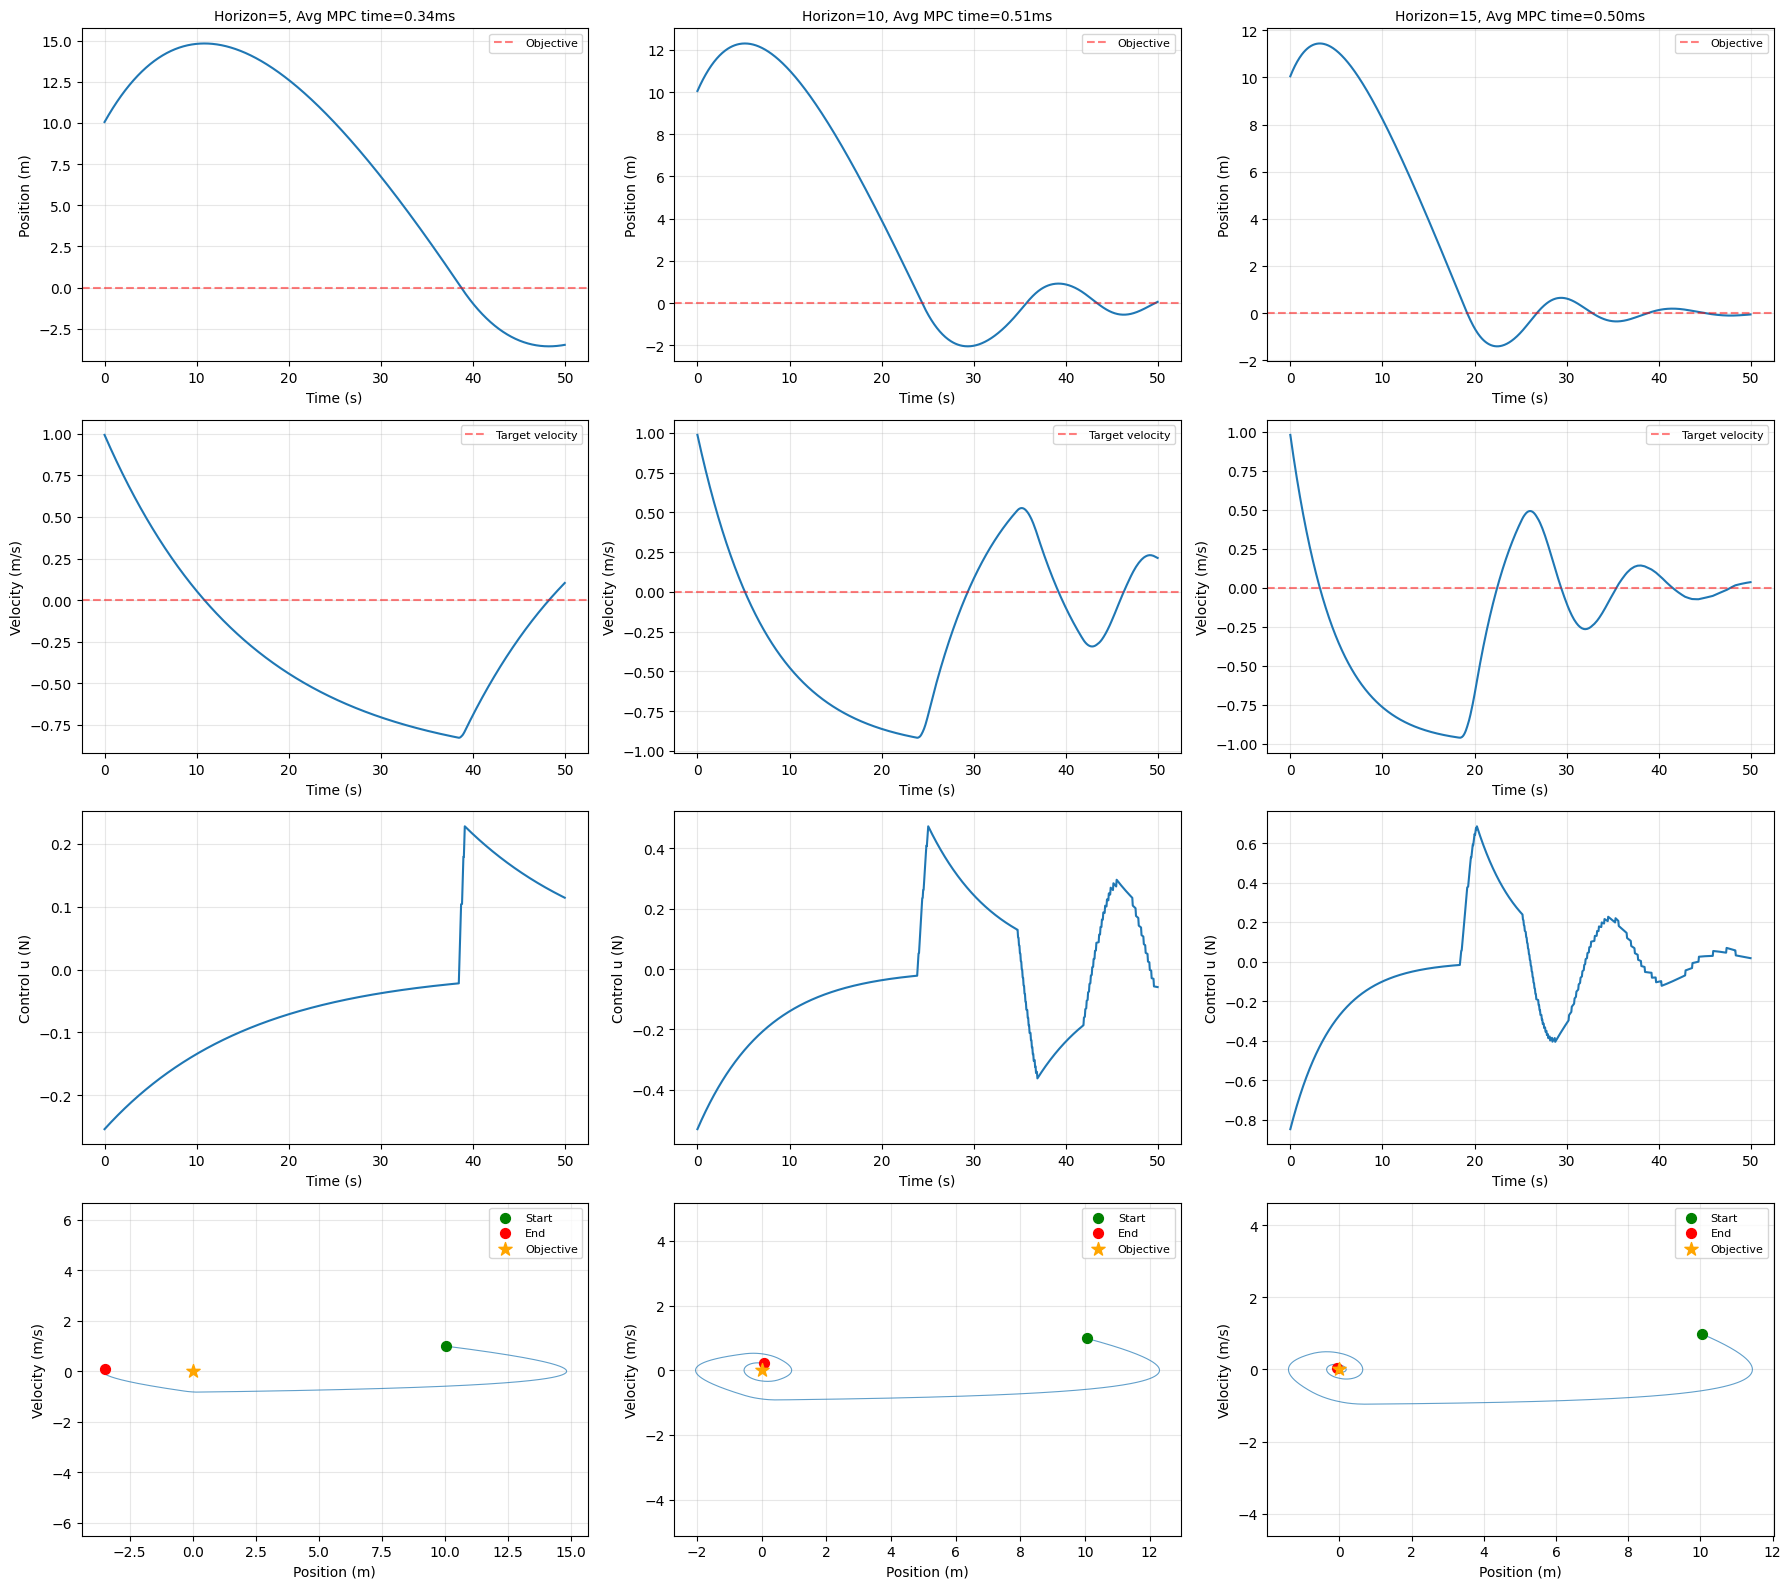

In [4]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(nrows=4, ncols=len(horizons), figsize=(6 * len(horizons), 16))

if len(horizons) == 1:
    axes = axes.reshape(-1, 1)

for col_idx, horizon in enumerate(horizons):
    x_traj = stats[horizon]["x_traj"]
    u_traj = stats[horizon]["u_traj"]
    avg_time = stats[horizon]["avg_mpc_time"]

    pos = x_traj[:, 0]
    vel = x_traj[:, 1]
    u = u_traj[:, 0]

    time_ax = np.arange(len(x_traj)) * dt

    axes[0, col_idx].plot(time_ax, pos, linewidth=1.5)
    axes[0, col_idx].axhline(y=0, color="r", linestyle="--", alpha=0.5, label="Objective")
    axes[0, col_idx].set_ylabel("Position (m)")
    axes[0, col_idx].set_xlabel("Time (s)")
    axes[0, col_idx].grid(True, alpha=0.3)
    axes[0, col_idx].legend(fontsize=8)
    axes[0, col_idx].set_title(f"Horizon={horizon}, Avg MPC time={avg_time * 1000:.2f}ms", fontsize=10)

    axes[1, col_idx].plot(time_ax, vel, linewidth=1.5)
    axes[1, col_idx].axhline(y=0, color="r", linestyle="--", alpha=0.5, label="Target velocity")
    axes[1, col_idx].set_ylabel("Velocity (m/s)")
    axes[1, col_idx].set_xlabel("Time (s)")
    axes[1, col_idx].grid(True, alpha=0.3)
    axes[1, col_idx].legend(fontsize=8)

    axes[2, col_idx].plot(time_ax, u, linewidth=1.5)
    axes[2, col_idx].set_ylabel("Control u (N)")
    axes[2, col_idx].set_xlabel("Time (s)")
    axes[2, col_idx].grid(True, alpha=0.3)

    axes[3, col_idx].plot(pos, vel, linewidth=0.8, alpha=0.7)
    axes[3, col_idx].scatter(pos[0], vel[0], c="green", s=50, zorder=5, label="Start")
    axes[3, col_idx].scatter(pos[-1], vel[-1], c="red", s=50, zorder=5, label="End")
    axes[3, col_idx].scatter(0, 0, c="orange", s=100, marker="*", zorder=5, label="Objective")
    axes[3, col_idx].set_xlabel("Position (m)")
    axes[3, col_idx].set_ylabel("Velocity (m/s)")
    axes[3, col_idx].grid(True, alpha=0.3)
    axes[3, col_idx].axis("equal")
    axes[3, col_idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
import mediapy

mediapy.show_videos(vids, fps=10, height=400, width=700, columns=1)

horizon=5 This browser does not support the video tag.
horizon=10 This browser does not support the video tag.
horizon=15 This browser does not support the video tag.
